# **Smoke Detector (Fire Alarm Detector)**
----

## **Import Libraries**

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

from pathlib import Path
project_root = Path().resolve().parent
import sys
sys.path.insert(0, str(project_root))

from src.utils import *
from src.preprocessing import *
from src.modeling import *

import mlflow
import mlflow.sklearn
from imblearn.over_sampling import SMOTE
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.linear_model import LogisticRegression as LGR
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.ensemble import BaggingClassifier as BGC, RandomForestClassifier as RFC, AdaBoostClassifier as ABC, GradientBoostingClassifier as GBC
from sklearn.metrics import recall_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

import warnings
warnings.filterwarnings('ignore')

## **Open Configuration File**

In [2]:
config = load_config()
config

{'column_datetime': 'UTC',
 'columns_float': ['temperature',
  'humidity_pct',
  'pressure',
  'pm10',
  'pm25',
  'nc05',
  'nc10',
  'nc25'],
 'columns_int': ['tvoc', 'co2', 'raw_h2', 'raw_ethanol', 'fire_alarm'],
 'features': ['temperature',
  'humidity_pct',
  'pressure',
  'pm10',
  'tvoc',
  'co2',
  'raw_h2',
  'raw_ethanol'],
 'label': 'fire_alarm',
 'log_features': ['pm10', 'co2', 'tvoc'],
 'n_cv': 5,
 'n_iter': 50,
 'n_jobs': -1,
 'num_features': ['temperature',
  'humidity_pct',
  'pressure',
  'raw_h2',
  'raw_ethanol'],
 'params_abc': {'model__n_estimators': [10, 50, 100, 150, 200, 250],
  'model__learning_rate': [0.001, 0.01, 0.05, 0.1, 1]},
 'params_bgc': {'model__n_estimators': [10, 50, 100, 150, 200, 250]},
 'params_dt': {'model__max_depth': [2, 3, 4, 5, 6]},
 'params_gbc': {'model__n_estimators': [10, 50, 100, 150, 200, 250],
  'model__learning_rate': [0.001, 0.01, 0.05, 0.1, 1],
  'model__max_depth': [2, 3, 4, 5, 6]},
 'params_knn': {'model__n_neighbors': [2, 3, 4, 5

## **Load Data**

In [3]:
# load all serialized data
X_train = deserialize_data(path=project_root/config['path_data_X_train'])
X_valid = deserialize_data(path=project_root/config['path_data_X_valid'])
X_test = deserialize_data(path=project_root/config['path_data_X_test'])
y_train = deserialize_data(path=project_root/config['path_data_y_train'])
y_valid = deserialize_data(path=project_root/config['path_data_y_valid'])
y_test = deserialize_data(path=project_root/config['path_data_y_test'])

Data deserialized from /home/bagaskoroah/smoke_detector/data/interim/X_train.pkl
Data deserialized from /home/bagaskoroah/smoke_detector/data/interim/X_valid.pkl
Data deserialized from /home/bagaskoroah/smoke_detector/data/interim/X_test.pkl
Data deserialized from /home/bagaskoroah/smoke_detector/data/interim/y_train.pkl
Data deserialized from /home/bagaskoroah/smoke_detector/data/interim/y_valid.pkl
Data deserialized from /home/bagaskoroah/smoke_detector/data/interim/y_test.pkl


In [4]:
X_train.isna().sum()

temperature     0
humidity_pct    0
pressure        0
pm10            0
tvoc            0
co2             0
raw_h2          0
raw_ethanol     0
dtype: int64

## **Preprocess Data**

In [5]:
# build preprocessor object
log_pipe, num_pipe = build_pipeline()
preprocessor = build_preprocessor(log_pipe=log_pipe, num_pipe=num_pipe)

## **Modeling**

### **Define Metrics**

- Considering class 1 (fire detected) is the positive class.
- False positive:
    - Predicted: fire detected
    - Actual: no fire
- False Negative:
    - Predicted: no fire
    - Actual: fire exists
- False Negative is clearly the misclassification that has highest risk among others. So, recall metrics would be prioritized in this case.

### **Baseline Model**

In [6]:
y_train.value_counts(normalize=True)

fire_alarm
1    0.714634
0    0.285366
Name: proportion, dtype: float64

In [7]:
recall_base = build_baseline(X_train=X_train, y_train=y_train)
print('Recall Baseline:', recall_base)

Recall Baseline: 0.7131207060269229


### **Fit and Predict Models**

In [8]:
models = {
    "ABC": (ABC(), config['params_abc']),
    "BGC": (BGC(), config['params_bgc']),
    "DTC": (DTC(), config['params_dt']),
    "GBC": (GBC(), config['params_gbc']),
    "LGR": (LGR(), config['params_lgr']),
    "KNN": (KNN(), config['params_knn']),
    "RFC": (RFC(), config['params_rfc']),
}

for name, (model, params) in models.items():
    mlflow.set_tracking_uri(f'file://{project_root}/mlruns')
    mlflow.set_experiment('smoke_detector_project')
    with mlflow.start_run(run_name=name):
        mlflow.set_tag("model", name)
        build_cv_train(
            estimator=model,
            preprocessor=preprocessor,
            params=params,
            X_train=X_train,
            y_train=y_train
        )

2026/03/19 21:24:13 INFO mlflow.tracking.fluent: Experiment with name 'smoke_detector_project' does not exist. Creating a new experiment.


2026/03/19 21:26:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/19 21:27:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/19 21:27:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

In [9]:
# make results summary
runs = mlflow.search_runs()
runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.best_recall_cv,metrics.best_recall_train,params.model__max_depth,params.model__n_estimators,params.model__weights,params.model__n_neighbors,params.model__p,params.model__C,params.model__learning_rate,tags.model,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.type,tags.mlflow.source.name
0,4f953ad4dc53470c8f96603d1feae23c,101265825768109830,FINISHED,file:///home/bagaskoroah/smoke_detector/mlruns...,2026-03-19 14:35:03.405000+00:00,2026-03-19 14:36:30.322000+00:00,0.999497,0.999574,6,150,None,None,None,None,None,RFC,RFC,bagaskoroah,NOTEBOOK,3_modeling.ipynb
1,ba4af90d57674593a59c505624854fd8,101265825768109830,FINISHED,file:///home/bagaskoroah/smoke_detector/mlruns...,2026-03-19 14:34:16.113000+00:00,2026-03-19 14:35:03.402000+00:00,0.999972,1.000000,None,None,uniform,3,1,None,None,KNN,KNN,bagaskoroah,NOTEBOOK,3_modeling.ipynb
2,9c39f715c46b42dbbf15d7e66e1c4a9f,101265825768109830,FINISHED,file:///home/bagaskoroah/smoke_detector/mlruns...,2026-03-19 14:34:12.574000+00:00,2026-03-19 14:34:16.110000+00:00,0.975926,0.976240,None,None,None,None,None,0.01,None,LGR,LGR,bagaskoroah,NOTEBOOK,3_modeling.ipynb
3,72c1aa6f2567407e9f0792b81f909aa3,101265825768109830,FINISHED,file:///home/bagaskoroah/smoke_detector/mlruns...,2026-03-19 14:27:32.059000+00:00,2026-03-19 14:34:12.571000+00:00,1.000000,1.000000,4,100,None,None,None,None,0.001,GBC,GBC,bagaskoroah,NOTEBOOK,3_modeling.ipynb
4,b802d9a7ce3d483385e8a32c50816134,101265825768109830,FINISHED,file:///home/bagaskoroah/smoke_detector/mlruns...,2026-03-19 14:27:28.271000+00:00,2026-03-19 14:27:32.056000+00:00,0.999693,0.999818,6,None,None,None,None,None,None,DTC,DTC,bagaskoroah,NOTEBOOK,3_modeling.ipynb
5,03968d956668498cb7ec7e013b8e9076,101265825768109830,FINISHED,file:///home/bagaskoroah/smoke_detector/mlruns...,2026-03-19 14:26:27.876000+00:00,2026-03-19 14:27:28.267000+00:00,0.999972,1.000000,None,10,None,None,None,None,None,BGC,BGC,bagaskoroah,NOTEBOOK,3_modeling.ipynb
6,005b9755e9d14fbb8b7acda96449023c,101265825768109830,FINISHED,file:///home/bagaskoroah/smoke_detector/mlruns...,2026-03-19 14:24:13.544000+00:00,2026-03-19 14:26:27.873000+00:00,0.999832,0.999881,None,200,None,None,None,None,1,ABC,ABC,bagaskoroah,NOTEBOOK,3_modeling.ipynb


In [10]:
# obtain the best model
best_run = runs.sort_values(by='metrics.best_recall_cv', ascending=False).iloc[0]
run_id = best_run['run_id']

# load model from MLflow
best_model = mlflow.sklearn.load_model(f'runs:/{run_id}/model')
best_model

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The giv

### **Predict and Evaluate Valid Data**

In [11]:
# predict and evaluate recall using valid data
y_valid_pred, recall_valid = build_test(
    estimator=best_model,
    X_test=X_valid,
    y_test=y_valid
)
print('Recall Score Using Valid Data:', recall_valid)

Recall Score Using Valid Data: 1.0


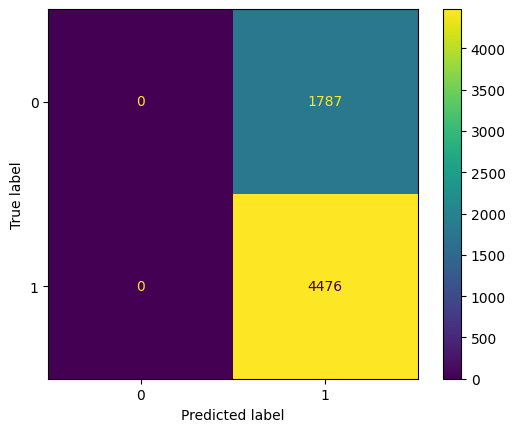

In [13]:
# show confusion matrix on valid data
cm_valid_display, tn_valid, fp_valid, tp_valid, fn_valid = confusion(y_test=y_valid, y_pred=y_valid_pred)

### **Predict and Evaluate Test Data**

In [15]:
# predict and evaluate recall using test data
y_test_pred, recall_test = build_test(
    estimator=best_model,
    X_test=X_test,
    y_test=y_test
)
print('Recall Score Using Test Data:', recall_test)

Recall Score Using Test Data: 1.0


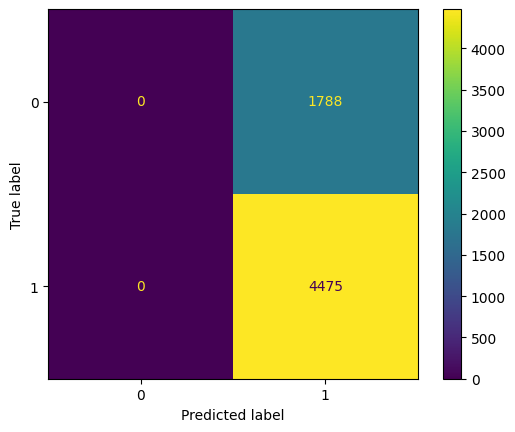

In [16]:
# show confusion matrix on test data
cm_test_display, tn_test, fp_test, tp_test, fn_test = confusion(y_test=y_test, y_pred=y_test_pred)

### **Serialize All Objects**

In [17]:
# save best model & update config
serialize_data(data=best_model, path=project_root/'models/best_model.pkl')
config = update_config(
    key = 'path_best_model',
    value = 'models/best_model.pkl',
    config = config
)

Data serialized to /home/bagaskoroah/smoke_detector/models/best_model.pkl
Config has been successfully updated. 
Key: path_best_model 
Value: models/best_model.pkl

